In [5]:
# 라이브러리 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
from tqdm.auto import tqdm
import pickle
import json

# 머신러닝
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, TimeSeriesSplit
import lightgbm as lgb
# XGBoostPruningCallback 삭제 (LightGBM은 불필요)

# Optuna
import optuna
from optuna.integration import XGBoostPruningCallback
from optuna.samplers import TPESampler

plt.rcParams['figure.figsize'] = (12, 6)
print("📚 라이브러리 로드 완료!")

📚 라이브러리 로드 완료!


In [6]:
# Google Colab 환경 확인 및 패키지 설치
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🔥 Google Colab 환경에서 실행 중...")
    !pip install xgboost optuna
    from google.colab import files, drive
    print("✅ 패키지 설치 완료!")
else:
    print("💻 로컬 환경에서 실행 중...")

💻 로컬 환경에서 실행 중...


In [7]:
# 데이터 파일 로드
if IN_COLAB:
    print("📁 파일 업로드 방법 선택:")
    print("1. 직접 업로드")
    print("2. Google Drive")

    method = input("선택 (1 또는 2): ")

    if method == "1":
        uploaded = files.upload()
        files_list = list(uploaded.keys())
        train_path = [f for f in files_list if 'train' in f.lower()][0]
        test_path = [f for f in files_list if 'test' in f.lower()][0]
    else:
        drive.mount('/content/drive')
        train_path = "/content/drive/MyDrive/train_heat.csv"
        test_path = "/content/drive/MyDrive/test_heat.csv"
else:
    train_path = '/Users/jisupark_1/workspace/star_track_python/PRJ_Meteo/dataset/train_data_2122.csv'
    test_path = '/Users/jisupark_1/workspace/star_track_python/PRJ_Meteo/dataset/train_data_2122.csv'

print(f"✅ 파일 경로 설정 완료")

✅ 파일 경로 설정 완료


In [8]:
def load_and_preprocess(train_path, test_path):
    print("📊 데이터 로드 및 전처리...")

    # 데이터 로드
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    def process_df(df):
        # 컬럼명 정리
        if 'Unnamed: 0' in df.columns:
            df = df.drop(columns=['Unnamed: 0'])
        df.columns = [col.replace('train_heat.', '') for col in df.columns]

        # 시간 변수
        df['datetime'] = pd.to_datetime(df['tm'], format='%Y%m%d%H')
        # df['year'] = df['datetime'].dt.year
        df['month'] = df['datetime'].dt.month
        # df['day'] = df['datetime'].dt.day
        df['hour'] = df['datetime'].dt.hour
        df['dayofweek'] = df['datetime'].dt.dayofweek

        # 결측치 처리
        missing_cols = ['ta', 'wd', 'ws', 'rn_day', 'rn_hr1', 'hm', 'si', 'ta_chi']
        if 'heat_demand' in df.columns:
            missing_cols.append('heat_demand')

        for col in missing_cols:
            if col in df.columns:
                df[col] = df[col].replace(-99, np.nan)

        # wd -9.9 결측치 처리
        df.loc[df['wd'] == -9.9, 'wd'] = np.nan

        # 일사량 야간 처리
        if 'si' in df.columns:
            night_mask = (df['hour'] < 8) | (df['hour'] > 18)
            df.loc[night_mask & df['si'].isna(), 'si'] = 0

        # 지사별 보간
        df = df.sort_values(['branch_id', 'datetime'])
        numeric_cols = df.select_dtypes(include=[np.number]).columns

        for branch in df['branch_id'].unique():
            mask = df['branch_id'] == branch
            df.loc[mask, numeric_cols] = df.loc[mask, numeric_cols].interpolate().fillna(method='ffill').fillna(method='bfill')

        return df

    train_df = process_df(train_df)
    test_df = process_df(test_df)

    print(f"   훈련: {train_df.shape}, 테스트: {test_df.shape}")
    print(f"   기간: {train_df['datetime'].min()} ~ {test_df['datetime'].max()}")
    print(f"   브랜치: {sorted(train_df['branch_id'].unique())}")

    return train_df, test_df

train_df, test_df = load_and_preprocess(train_path, test_path)

📊 데이터 로드 및 전처리...
   훈련: (332861, 15), 테스트: (332861, 15)
   기간: 2021-01-01 01:00:00 ~ 2022-12-31 23:00:00
   브랜치: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S']


### 파생변수

In [9]:
import numpy as np
import pandas as pd
from scipy.fft import fft

def create_features(df):
    """통합된 파생변수 생성 함수 - 기본 변수 + 고급 변수 모두 포함"""
    df = df.copy()
    
    # ======================== 기본 파생변수들 ========================
    
    # ⭐ HDD (수치형)
    if 'ta' in df.columns:
        df['HDD_18'] = np.maximum(18 - df['ta'], 0)
        df['HDD_20'] = np.maximum(20 - df['ta'], 0)

    # ⭐ 체감온도 (한국 기상청 공식)
    if 'ta' in df.columns:
        df['wind_chill'] = df['ta'].copy()  # 기본값은 기온
        
        # 겨울철 체감온도 (기온 10°C 이하, 풍속 1.3 m/s 이상)
        if 'ws' in df.columns:
            winter_mask = (df['ta'] <= 10) & (df['ws'] >= 1.3)
            # 풍속 m/s를 km/h로 변환 (×3.6)
            V_kmh = df['ws'] * 3.6
            df.loc[winter_mask, 'wind_chill'] = (
                13.12 + 0.6215 * df.loc[winter_mask, 'ta'] 
                - 11.37 * (V_kmh.loc[winter_mask] ** 0.16) 
                + 0.3965 * (V_kmh.loc[winter_mask] ** 0.16) * df.loc[winter_mask, 'ta']
            )
        
        # 여름철 체감온도 (기온 > 10°C이고 습도 데이터가 있을 때)
        if 'hm' in df.columns:
            summer_mask = df['ta'] > 10
            
            # Stull의 습구온도 추정식
            Ta = df.loc[summer_mask, 'ta']
            RH = df.loc[summer_mask, 'hm']
            
            # 습구온도 계산
            Tw = (Ta * np.arctan(0.151977 * (RH + 8.313659) ** 0.5) 
                  + np.arctan(Ta + RH) 
                  - np.arctan(RH - 1.67633) 
                  + 0.00391838 * (RH ** 1.5) * np.arctan(0.023101 * RH) 
                  - 4.686035)
            
            # 여름철 체감온도 계산
            df.loc[summer_mask, 'wind_chill'] = (
                -0.2442 + 0.55399 * Tw + 0.45535 * Ta 
                - 0.0022 * (Tw ** 2) + 0.00278 * Tw * Ta + 3.0
            )

    # ⭐ heating_season (범주형) - 3시즌
    def assign_season(month):
        if month in [5, 6, 7, 8, 9]:  # 비난방
            return 0
        elif month in [10, 11, 12, 1]:  # 난방 상승
            return 1
        else:  # month in [2, 3, 4]  # 난방 하강
            return 2

    df['heating_season'] = df['month'].apply(assign_season)

    # 시간대 범주형
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_peak_morning'] = ((df['hour'] >= 7) & (df['hour'] <= 9)).astype(int)
    df['is_peak_evening'] = ((df['hour'] >= 18) & (df['hour'] <= 22)).astype(int)
    df['is_night'] = ((df['hour'] >= 23) | (df['hour'] <= 5)).astype(int)

    # 피크시간 통합
    df['peak_time_category'] = 0
    df.loc[df['is_peak_morning'] == 1, 'peak_time_category'] = 1
    df.loc[df['is_peak_evening'] == 1, 'peak_time_category'] = 2
    df.loc[df['is_night'] == 1, 'peak_time_category'] = 3

    # ⭐ 기온 범주 (범주형)
    if 'ta' in df.columns:
        df['temp_category'] = pd.cut(df['ta'],
                                   bins=[-np.inf, 0, 10, 20, 30, np.inf],
                                   labels=[0, 1, 2, 3, 4]).astype(int)

    # ⭐ 강수 강도 (범주형)
    if 'rn_day' in df.columns:
        df['rain_intensity'] = pd.cut(df['rn_day'],
                                   bins=[-1, 0, 1, 5, 10, np.inf],
                                   labels=[0, 1, 2, 3, 4]).astype(int)

    # ⭐ 순환형 인코딩 (시간 cos, sin)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

    # 시간 기반 파생변수
    df['hour_squared'] = df['hour'] ** 2
    df['month_day_interaction'] = df['month'] * df['datetime'].dt.day
    
    # 기온 관련 파생변수
    if 'ta' in df.columns:
        df['ta_squared'] = df['ta'] ** 2
        df['ta_cubed'] = df['ta'] ** 3
    
    # 습도와 기온 상호작용
    if 'hm' in df.columns and 'ta' in df.columns:
        df['hm_ta_interaction'] = df['hm'] * df['ta']

    # ======================== 고급 파생변수들 ========================
    
    # ⭐ DCI (Discomfort Index)
    if 'ta' in df.columns and 'hm' in df.columns:
        df['DCI'] = 0.81 * df['ta'] + 0.01 * df['hm'] * (0.99 * df['ta'] - 14.3) + 46.3
    
    # ⭐ 연중일 (Day of Year) - 365주기
    df['day_of_year'] = df['datetime'].dt.dayofyear
    df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)
    
    # ⭐ 3시간 전 평균값들 (최대 24시간까지 - 8개 변수)
    weather_vars = ['ta', 'hm', 'ws', 'wd', 'rn_hr1', 'si', 'ta_chi']
    if 'wind_chill' in df.columns:
        weather_vars.append('wind_chill')
    
    df = df.sort_values(['branch_id', 'datetime'])
    
    for var in weather_vars:
        if var in df.columns:
            for lag_hours in [3, 6, 9, 12, 15, 18, 21, 24]:
                col_name = f'{var}_lag_{lag_hours}h_mean'
                df[col_name] = df.groupby('branch_id')[var].transform(
                    lambda x: x.shift(lag_hours).rolling(window=3, min_periods=1).mean()
                )
    
    # ⭐ 푸리에 변환 (N차 조화)
    def fourier_features(series, n_harmonics=3):
        """시계열 데이터의 푸리에 변환 특성 추출"""
        features = {}
        for n in range(1, n_harmonics + 1):
            # 주파수 기반 sin, cos 특성
            freq = 2 * np.pi * n / len(series)
            features[f'sin_{n}'] = np.sin(freq * np.arange(len(series)))
            features[f'cos_{n}'] = np.cos(freq * np.arange(len(series)))
        return features
    
    # 각 지사별로 푸리에 특성 생성
    for var in ['ta', 'hm', 'ws', 'wind_chill']:
        if var in df.columns:
            for branch in df['branch_id'].unique():
                mask = df['branch_id'] == branch
                branch_data = df.loc[mask, var].dropna()
                if len(branch_data) > 0:
                    fourier_dict = fourier_features(branch_data, n_harmonics=3)
                    for harm_name, harm_values in fourier_dict.items():
                        col_name = f'{var}_fourier_{harm_name}'
                        if col_name not in df.columns:
                            df[col_name] = 0.0
                        df.loc[mask, col_name] = harm_values[:sum(mask)]
    
    # ⭐ 기온 lag 변수들
    if 'ta' in df.columns:
        for lag in [1, 2, 3]:
            df[f'ta_lag_{lag}h'] = df.groupby('branch_id')['ta'].shift(lag)
    
    # ⭐ 기온 차이 변수들
    if 'ta' in df.columns:
        df['ta_diff_24h'] = df['ta'] - df.groupby('branch_id')['ta'].shift(24)
        df['ta_diff_12h'] = df['ta'] - df.groupby('branch_id')['ta'].shift(12)
        df['ta_diff_6h'] = df['ta'] - df.groupby('branch_id')['ta'].shift(6)
    
    # ⭐ 기온 20도 기준 범주
    if 'ta' in df.columns:
        df['temp_category20'] = (df['ta'] >= 20).astype(int)
    
    # ⭐ 일교차 계산
    if 'ta' in df.columns:
        daily_temp_stats = df.groupby(['branch_id', df['datetime'].dt.date])['ta'].agg(['min', 'max']).reset_index()
        daily_temp_stats['daily_temp_range'] = daily_temp_stats['max'] - daily_temp_stats['min']
        daily_temp_stats['date'] = daily_temp_stats['datetime']
        
        # 전날 일교차와의 차이
        daily_temp_stats['daily_temp_range_diff'] = daily_temp_stats.groupby('branch_id')['daily_temp_range'].diff()
        
        # 원본 데이터에 병합
        df['date'] = df['datetime'].dt.date
        df = df.merge(daily_temp_stats[['branch_id', 'date', 'daily_temp_range', 'daily_temp_range_diff']], 
                     on=['branch_id', 'date'], how='left')
        df = df.drop('date', axis=1)
    
    # ⭐ 새로운 시간대 범주
    df['is_peak_morning_27'] = ((df['hour'] >= 2) & (df['hour'] <= 7)).astype(int)
    df['is_peak_morning_710'] = ((df['hour'] >= 7) & (df['hour'] <= 10)).astype(int)
    
    # ⭐ 계절 (4계절)
    def assign_four_seasons(month):
        if month in [3, 4, 5]:  # 봄
            return 0
        elif month in [6, 7, 8]:  # 여름
            return 1
        elif month in [9, 10, 11]:  # 가을
            return 2
        else:  # 겨울 (12, 1, 2)
            return 3
    
    df['season'] = df['month'].apply(assign_four_seasons)
    
    # ⭐ 공휴일 (간단한 주요 공휴일만 - 실제로는 더 복잡한 로직 필요)
    def is_holiday(date):
        # 주요 고정 공휴일들
        month = date.month
        day = date.day
        
        # 신정, 삼일절, 어린이날, 광복절, 개천절, 한글날, 성탄절
        fixed_holidays = [(1, 1), (3, 1), (5, 5), (8, 15), (10, 3), (10, 9), (12, 25)]
        
        if (month, day) in fixed_holidays:
            return 1
        
        # 설날, 추석은 음력이므로 간단히 처리 (실제로는 음력->양력 변환 필요)
        # 여기서는 대략적인 날짜로 설정
        if (month == 2 and 10 <= day <= 12) or (month == 9 and 20 <= day <= 22):
            return 1
        
        return 0
    
    df['is_holiday'] = df['datetime'].dt.date.apply(is_holiday)
    
    # ⭐ 추가 상호작용 변수들
    if 'ta' in df.columns and 'hm' in df.columns:
        df['ta_humidity_interaction'] = df['ta'] * df['hm']
    
    if 'ws' in df.columns and 'ta' in df.columns:
        df['wind_temp_interaction'] = df['ws'] * df['ta']
    
    if 'rn_day' in df.columns and 'season' in df.columns:
        df['rain_season_interaction'] = df['rn_day'] * df['season']

    return df




In [10]:

train_df = create_features(train_df)
test_df = create_features(test_df)
print(f"✅ 통합 파생변수 생성 완료: {train_df.shape[1]}개 컬럼")

✅ 통합 파생변수 생성 완료: 145개 컬럼


### 시계열 정상성 확인

In [11]:
import numpy as np
import pandas as pd
import warnings
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

warnings.filterwarnings('ignore')

In [12]:


def check_stationarity(series, series_name=""):
    """시계열 데이터의 정상성 확인 (ADF 테스트)"""
    result = adfuller(series.dropna())
    is_stationary = result[1] <= 0.05
    return {
        'series': series_name,
        'adf_statistic': result[0],
        'p_value': result[1],
        'is_stationary': is_stationary,
        'critical_values': result[4]
    }

def make_stationary(series):
    """시계열을 정상화 (차분)"""
    # 1차 차분
    diff_series = series.diff().dropna()
    
    # 정상성 확인
    adf_result = adfuller(diff_series.dropna())
    if adf_result[1] <= 0.05:
        return diff_series, 1
    
    # 2차 차분
    diff2_series = diff_series.diff().dropna()
    adf_result2 = adfuller(diff2_series.dropna())
    if adf_result2[1] <= 0.05:
        return diff2_series, 2
    
    # 3차 차분까지만 시도
    diff3_series = diff2_series.diff().dropna()
    return diff3_series, 3

## Granger Causality Test

### 단일 지사

In [37]:


def granger_causality_analysis(df, target_col='heat_demand', max_lag=5, 
                              branch_id=None, significance_level=0.05):
    """
    Granger Causality 분석 수행
    
    Parameters:
    - df: 데이터프레임
    - target_col: 목표 변수 (기본: heat_demand)
    - max_lag: 최대 시차 (기본: 5)
    - branch_id: 특정 지사 분석 (None이면 모든 지사)
    - significance_level: 유의수준 (기본: 0.05)
    """
    
    # 특정 지사 데이터 추출 (지정된 경우)
    if branch_id is not None:
        df_analysis = df[df['branch_id'] == branch_id].copy()
        print(f"🔍 지사 {branch_id} 데이터 분석")
    else:
        # 전체 데이터에서 첫 번째 지사만 사용 (시계열 분석을 위해)
        first_branch = df['branch_id'].iloc[0]
        df_analysis = df[df['branch_id'] == first_branch].copy()
        print(f"🔍 지사 {first_branch} 데이터로 대표 분석")
    
    # 시간순 정렬
    df_analysis = df_analysis.sort_values('datetime').reset_index(drop=True)
    
    # 수치형 변수만 선택
    numeric_cols = df_analysis.select_dtypes(include=[np.number]).columns.tolist()
    
    # 분석에서 제외할 변수들
    exclude_cols = ['tm', 'branch_id', target_col, 'day_of_year']
    analysis_cols = [col for col in numeric_cols if col not in exclude_cols]
    
    print(f"📊 분석 대상 변수: {len(analysis_cols)}개")
    print(f"📅 분석 기간: {df_analysis['datetime'].min()} ~ {df_analysis['datetime'].max()}")
    print(f"📈 데이터 포인트: {len(df_analysis)}개")
    
    # 결과 저장용 리스트
    causality_results = []
    stationarity_results = []
    
    # 목표 변수 정상성 확인
    target_series = df_analysis[target_col].dropna()
    target_stat = check_stationarity(target_series, target_col)
    stationarity_results.append(target_stat)
    
    # 목표 변수 정상화
    if not target_stat['is_stationary']:
        target_stationary, target_diff_order = make_stationary(target_series)
        print(f"⚠️  {target_col}을 {target_diff_order}차 차분으로 정상화")
    else:
        target_stationary = target_series
        target_diff_order = 0
    
    print("\n🔄 Granger Causality 테스트 진행 중...")
    
    # 각 변수에 대해 Granger Causality 테스트
    for col in tqdm(analysis_cols, desc="변수 분석"):
        try:
            # 해당 변수의 데이터 추출
            var_series = df_analysis[col].dropna()
            
            # 두 시계열의 공통 인덱스 찾기
            common_index = target_series.index.intersection(var_series.index)
            if len(common_index) < max_lag + 10:  # 최소 데이터 요구량
                continue
                
            var_common = var_series.loc[common_index]
            target_common = target_series.loc[common_index]
            
            # 변수 정상성 확인
            var_stat = check_stationarity(var_common, col)
            stationarity_results.append(var_stat)
            
            # 변수 정상화
            if not var_stat['is_stationary']:
                var_stationary, var_diff_order = make_stationary(var_common)
            else:
                var_stationary = var_common
                var_diff_order = 0
            
            # 목표 변수도 같은 차분 차수로 맞춤
            if target_diff_order == 0 and var_diff_order == 0:
                final_target = target_common
                final_var = var_stationary
            elif target_diff_order >= var_diff_order:
                final_target = target_stationary
                final_var = var_stationary
                # 인덱스 맞춤
                min_len = min(len(final_target), len(final_var))
                final_target = final_target.iloc[-min_len:]
                final_var = final_var.iloc[-min_len:]
            else:
                # 목표 변수를 더 차분
                temp_target = target_common
                for _ in range(var_diff_order - target_diff_order):
                    temp_target = temp_target.diff().dropna()
                final_target = temp_target
                final_var = var_stationary
                # 인덱스 맞춤
                min_len = min(len(final_target), len(final_var))
                final_target = final_target.iloc[-min_len:]
                final_var = final_var.iloc[-min_len:]
            
            # 데이터 길이 확인
            if len(final_target) < max_lag + 10 or len(final_var) < max_lag + 10:
                continue
            
            # Granger Causality 테스트용 데이터 준비
            # [목표변수, 설명변수] 순서로 배열
            test_data = np.column_stack([final_target, final_var])
            test_df = pd.DataFrame(test_data, columns=[target_col, col])
            
            # Granger Causality 테스트 수행
            gc_result = grangercausalitytests(test_df, maxlag=max_lag, verbose=False)
            
            # 결과 정리 (각 lag에 대한 p-value 추출)
            for lag in range(1, max_lag + 1):
                if lag in gc_result:
                    # F-test 결과 추출
                    f_test = gc_result[lag][0]['ssr_ftest']
                    p_value = f_test[1]
                    f_stat = f_test[0]
                    
                    causality_results.append({
                        'variable': col,
                        'lag': lag,
                        'f_statistic': f_stat,
                        'p_value': p_value,
                        'is_significant': p_value < significance_level,
                        'var_diff_order': var_diff_order,
                        'target_diff_order': target_diff_order
                    })
        
        except Exception as e:
            print(f"❌ {col} 분석 중 오류: {str(e)}")
            continue
    
    # 결과를 DataFrame으로 변환
    causality_df = pd.DataFrame(causality_results)
    stationarity_df = pd.DataFrame(stationarity_results)
    
    return causality_df, stationarity_df



IndentationError: unexpected indent (3009992776.py, line 20)

In [38]:
def analyze_causality_results(causality_df, top_n=20):
    """Granger Causality 결과 분석 및 시각화"""
    
    if causality_df.empty:
        print("❌ 분석 결과가 없습니다.")
        return
    
    print("\n" + "="*80)
    print("📊 GRANGER CAUSALITY 분석 결과")
    print("="*80)
    
    # 1. 전체 유의한 결과 요약
    significant_results = causality_df[causality_df['is_significant']]
    print(f"\n🎯 유의한 인과관계 발견: {len(significant_results)}개 (전체 {len(causality_df)}개 중)")
    
    if len(significant_results) == 0:
        print("⚠️  유의한 인과관계를 발견하지 못했습니다.")
        return
    
    # 2. 최적 시차별 요약
    print(f"\n📈 시차별 유의한 결과:")
    lag_summary = significant_results.groupby('lag').size().sort_values(ascending=False)
    for lag, count in lag_summary.head().items():
        print(f"   Lag {lag}: {count}개 변수")
    
    # 3. 가장 강한 인과관계 (p-value 기준)
    print(f"\n🏆 가장 강한 인과관계 TOP {top_n}:")
    top_results = significant_results.nsmallest(top_n, 'p_value')
    
    for idx, row in top_results.iterrows():
        print(f"   {row['variable']} → heat_demand (lag={row['lag']}, p={row['p_value']:.4f})")
    
    # 4. 변수별 최적 시차 (가장 낮은 p-value)
    print(f"\n🎯 변수별 최적 시차:")
    best_by_variable = significant_results.loc[significant_results.groupby('variable')['p_value'].idxmin()]
    best_by_variable_sorted = best_by_variable.sort_values('p_value').head(15)
    
    for idx, row in best_by_variable_sorted.iterrows():
        print(f"   {row['variable']}: lag={row['lag']} (p={row['p_value']:.4f})")
    
    # 5. 시각화
    plt.figure(figsize=(15, 10))
    
    # 5-1. 변수별 최소 p-value 히트맵
    plt.subplot(2, 2, 1)
    top_vars = best_by_variable_sorted.head(20)
    
    plt.barh(range(len(top_vars)), -np.log10(top_vars['p_value']))
    plt.yticks(range(len(top_vars)), top_vars['variable'], fontsize=8)
    plt.xlabel('-log10(p-value)')
    plt.title('상위 20개 변수의 Granger Causality 강도')
    plt.axvline(-np.log10(0.05), color='red', linestyle='--', alpha=0.7, label='p=0.05')
    plt.legend()
    
    # 5-2. 시차별 유의한 변수 수
    plt.subplot(2, 2, 2)
    lag_counts = significant_results.groupby('lag').size()
    plt.bar(lag_counts.index, lag_counts.values)
    plt.xlabel('Lag (시차)')
    plt.ylabel('유의한 변수 수')
    plt.title('시차별 유의한 Granger Causality 변수 수')
    
    # 5-3. p-value 분포
    plt.subplot(2, 2, 3)
    plt.hist(significant_results['p_value'], bins=20, alpha=0.7, edgecolor='black')
    plt.xlabel('p-value')
    plt.ylabel('빈도')
    plt.title('유의한 결과의 p-value 분포')
    plt.axvline(0.05, color='red', linestyle='--', alpha=0.7, label='p=0.05')
    plt.legend()
    
    # 5-4. 변수 유형별 분석 (변수명 패턴으로 분류)
    plt.subplot(2, 2, 4)
    
    # 변수 유형 분류
    def classify_variable(var_name):
        if 'lag_' in var_name and 'h_mean' in var_name:
            return 'Lag Variables'
        elif 'fourier_' in var_name:
            return 'Fourier Transform'
        elif any(x in var_name for x in ['sin', 'cos']):
            return 'Cyclical Encoding'
        elif 'ta' in var_name or 'temp' in var_name or 'HDD' in var_name:
            return 'Temperature Related'
        elif 'interaction' in var_name:
            return 'Interaction'
        elif any(x in var_name for x in ['peak', 'weekend', 'holiday', 'season']):
            return 'Time/Season'
        else:
            return 'Others'
    
    best_by_variable_sorted['var_type'] = best_by_variable_sorted['variable'].apply(classify_variable)
    type_counts = best_by_variable_sorted['var_type'].value_counts()
    
    plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%')
    plt.title('유의한 변수의 유형별 분포')
    
    plt.tight_layout()
    plt.show()
    
    return top_results, best_by_variable_sorted



### 인과분석 결과 해석 및 시각화

In [12]:
# 사용 예시
def run_granger_analysis(train_df, target_col='heat_demand', max_lag=5, branch_id=None):
    """Granger Causality 분석 실행 함수"""
    
    print("🚀 Granger Causality 분석 시작")
    print(f"📊 데이터 크기: {train_df.shape}")
    
    # Granger Causality 분석 수행
    causality_results, stationarity_results = granger_causality_analysis(
        train_df, 
        target_col=target_col, 
        max_lag=max_lag, 
        branch_id=branch_id
    )
    
    # 결과 분석
    if not causality_results.empty:
        top_results, best_vars = analyze_causality_results(causality_results)
        
        # 결과 저장
        causality_results.to_csv('granger_causality_results.csv', index=False)
        stationarity_results.to_csv('stationarity_test_results.csv', index=False)
        
        print(f"\n💾 결과가 CSV 파일로 저장되었습니다.")
        print(f"   - granger_causality_results.csv")
        print(f"   - stationarity_test_results.csv")
        
        return causality_results, stationarity_results, top_results, best_vars
    else:
        print("❌ 분석 결과가 없습니다.")
        return None, None, None, None

# 실행 코드
if __name__ == "__main__":
    # 분석 실행 (train_df가 이미 로드되어 있다고 가정)
    results = run_granger_analysis(
        train_df, 
        target_col='heat_demand', 
        max_lag=5,  # 최대 5시간 시차까지 분석
        branch_id=None  # 특정 지사 지정 시 해당 지사 ID 입력
    )
    
    if results[0] is not None:
        causality_df, stationarity_df, top_results, best_vars = results
        print(f"\n✅ 분석 완료! 총 {len(causality_df)}개 결과 중 {len(causality_df[causality_df['is_significant']])}개가 유의합니다.")

🚀 Granger Causality 분석 시작
📊 데이터 크기: (332861, 145)


NameError: name 'granger_causality_analysis' is not defined

### 전체 지사 대상

In [13]:
import numpy as np
import pandas as pd
import warnings
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
import gc

warnings.filterwarnings('ignore')

In [14]:


def check_stationarity(series, series_name=""):
    """시계열 데이터의 정상성 확인 (ADF 테스트)"""
    try:
        result = adfuller(series.dropna())
        is_stationary = result[1] <= 0.05
        return {
            'series': series_name,
            'adf_statistic': result[0],
            'p_value': result[1],
            'is_stationary': is_stationary,
            'critical_values': result[4]
        }
    except:
        return {
            'series': series_name,
            'adf_statistic': np.nan,
            'p_value': 1.0,
            'is_stationary': False,
            'critical_values': {}
        }

def make_stationary(series):
    """시계열을 정상화 (차분)"""
    try:
        # 1차 차분
        diff_series = series.diff().dropna()
        
        # 정상성 확인
        adf_result = adfuller(diff_series.dropna())
        if adf_result[1] <= 0.05:
            return diff_series, 1
        
        # 2차 차분
        diff2_series = diff_series.diff().dropna()
        adf_result2 = adfuller(diff2_series.dropna())
        if adf_result2[1] <= 0.05:
            return diff2_series, 2
        
        # 3차 차분까지만 시도
        diff3_series = diff2_series.diff().dropna()
        return diff3_series, 3
    except:
        return series, 0

In [15]:


def granger_causality_single_branch(branch_data, branch_id, target_col='heat_demand', 
                                  max_lag=5, significance_level=0.05):
    """단일 지사에 대한 Granger Causality 분석 (안정적 버전)"""
    
    try:
        # 시간순 정렬
        df_analysis = branch_data.sort_values('datetime').reset_index(drop=True)
        
        # 수치형 변수만 선택
        numeric_cols = df_analysis.select_dtypes(include=[np.number]).columns.tolist()
        
        # 분석에서 제외할 변수들
        exclude_cols = ['tm', 'branch_id', target_col, 'day_of_year']
        analysis_cols = [col for col in numeric_cols if col not in exclude_cols]
        
        # 결과 저장용 리스트
        causality_results = []
        
        # 목표 변수 정상성 확인 및 정상화
        target_series = df_analysis[target_col].dropna()
        if len(target_series) < max_lag + 20:
            return [], f"insufficient_data_{len(target_series)}"
        
        target_stat = check_stationarity(target_series, target_col)
        
        if not target_stat['is_stationary']:
            target_stationary, target_diff_order = make_stationary(target_series)
        else:
            target_stationary = target_series
            target_diff_order = 0
        
        # 각 변수에 대해 Granger Causality 테스트
        successful_tests = 0
        failed_tests = 0
        
        for col in analysis_cols:
            try:
                # 해당 변수의 데이터 추출
                var_series = df_analysis[col].dropna()
                
                # 두 시계열의 공통 인덱스 찾기
                common_index = target_series.index.intersection(var_series.index)
                if len(common_index) < max_lag + 20:
                    failed_tests += 1
                    continue
                    
                var_common = var_series.loc[common_index]
                target_common = target_series.loc[common_index]
                
                # 무한값이나 NaN 제거
                valid_mask = np.isfinite(var_common) & np.isfinite(target_common)
                var_common = var_common[valid_mask]
                target_common = target_common[valid_mask]
                
                if len(var_common) < max_lag + 20:
                    failed_tests += 1
                    continue
                
                # 변수 정상성 확인 및 정상화
                var_stat = check_stationarity(var_common, col)
                
                if not var_stat['is_stationary']:
                    var_stationary, var_diff_order = make_stationary(var_common)
                else:
                    var_stationary = var_common
                    var_diff_order = 0
                
                # 목표 변수도 같은 차분 차수로 맞춤
                if target_diff_order == 0 and var_diff_order == 0:
                    final_target = target_common
                    final_var = var_stationary
                elif target_diff_order >= var_diff_order:
                    final_target = target_stationary
                    final_var = var_stationary
                    # 인덱스 맞춤
                    min_len = min(len(final_target), len(final_var))
                    final_target = final_target.iloc[-min_len:].reset_index(drop=True)
                    final_var = final_var.iloc[-min_len:].reset_index(drop=True)
                else:
                    # 목표 변수를 더 차분
                    temp_target = target_common.copy()
                    for _ in range(var_diff_order - target_diff_order):
                        temp_target = temp_target.diff().dropna()
                    final_target = temp_target.reset_index(drop=True)
                    final_var = var_stationary.reset_index(drop=True)
                    # 인덱스 맞춤
                    min_len = min(len(final_target), len(final_var))
                    final_target = final_target.iloc[-min_len:]
                    final_var = final_var.iloc[-min_len:]
                
                # 데이터 길이 확인
                if len(final_target) < max_lag + 20 or len(final_var) < max_lag + 20:
                    failed_tests += 1
                    continue
                
                # 무한값 재확인
                if not (np.isfinite(final_target).all() and np.isfinite(final_var).all()):
                    failed_tests += 1
                    continue
                
                # Granger Causality 테스트용 데이터 준비
                test_data = np.column_stack([final_target.values, final_var.values])
                test_df = pd.DataFrame(test_data, columns=[target_col, col])
                
                # Granger Causality 테스트 수행
                gc_result = grangercausalitytests(test_df, maxlag=max_lag, verbose=False)
                
                # 결과 정리
                for lag in range(1, max_lag + 1):
                    if lag in gc_result:
                        try:
                            f_test = gc_result[lag][0]['ssr_ftest']
                            p_value = f_test[1]
                            f_stat = f_test[0]
                            
                            # 유효한 값인지 확인
                            if np.isfinite(p_value) and np.isfinite(f_stat):
                                causality_results.append({
                                    'branch_id': branch_id,
                                    'variable': col,
                                    'lag': lag,
                                    'f_statistic': f_stat,
                                    'p_value': p_value,
                                    'is_significant': p_value < significance_level,
                                    'var_diff_order': var_diff_order,
                                    'target_diff_order': target_diff_order
                                })
                        except:
                            continue
                
                successful_tests += 1
                
                # 메모리 정리
                del var_common, target_common, final_target, final_var, test_data, test_df, gc_result
            
            except Exception as e:
                failed_tests += 1
                continue
        
        # 메모리 정리
        del df_analysis, target_series, target_stationary
        gc.collect()
        
        return causality_results, f"completed_{successful_tests}_tests_failed_{failed_tests}"
    
    except Exception as e:
        return [], f"error_{str(e)}"

In [16]:


def run_sequential_granger_analysis(df, target_col='heat_demand', max_lag=5, 
                                  significance_level=0.05, sample_branches=None):
    """순차적 Granger Causality 분석 (안정적 버전)"""
    
    print("🚀 순차적 Granger Causality 분석 시작")
    print(f"📊 전체 데이터 크기: {df.shape}")
    
    # 지사별 데이터 분할
    branches = df['branch_id'].unique()
    
    # 샘플링 옵션
    if sample_branches is not None:
        if isinstance(sample_branches, int):
            branches = branches[:sample_branches]
        else:
            branches = sample_branches
    
    print(f"🏢 분석 대상 지사: {len(branches)}개")
    
    # 지사별 데이터 준비 및 필터링
    valid_branches = []
    for branch_id in branches:
        branch_data = df[df['branch_id'] == branch_id].copy()
        if len(branch_data) >= max_lag + 50:  # 최소 데이터 요구량
            valid_branches.append((branch_data, branch_id))
    
    print(f"📈 실제 분석 지사: {len(valid_branches)}개 (데이터 충분한 지사)")
    
    # 순차적 분석 수행
    all_results = []
    branch_status = {}
    
    start_time = time.time()
    
    for i, (branch_data, branch_id) in enumerate(tqdm(valid_branches, desc="지사별 분석 진행")):
        try:
            # 단일 지사 분석
            causality_results, status = granger_causality_single_branch(
                branch_data, branch_id, target_col, max_lag, significance_level
            )
            
            # 결과 저장
            all_results.extend(causality_results)
            branch_status[branch_id] = status
            
            # 중간 진행상황 출력 (10개 지사마다)
            if (i + 1) % 10 == 0:
                elapsed = time.time() - start_time
                remaining = (elapsed / (i + 1)) * (len(valid_branches) - i - 1)
                print(f"   진행: {i+1}/{len(valid_branches)} 지사 완료 (예상 남은 시간: {remaining/60:.1f}분)")
            
            # 메모리 정리
            del branch_data, causality_results
            gc.collect()
            
        except Exception as e:
            branch_status[branch_id] = f"error_{str(e)}"
            print(f"❌ 지사 {branch_id} 분석 실패: {str(e)}")
            continue
    
    elapsed_time = time.time() - start_time
    print(f"⏱️  총 분석 시간: {elapsed_time/60:.1f}분")
    
    # 결과 정리
    if all_results:
        causality_df = pd.DataFrame(all_results)
        
        # 지사별 분석 상태 출력
        print(f"\n📋 지사별 분석 상태:")
        completed_branches = sum(1 for status in branch_status.values() if 'completed' in status)
        error_branches = sum(1 for status in branch_status.values() if 'error' in status)
        
        print(f"   ✅ 성공: {completed_branches}개 지사")
        print(f"   ❌ 실패: {error_branches}개 지사")
        
        # 전체 결과 요약
        total_tests = len(causality_df)
        significant_tests = len(causality_df[causality_df['is_significant']])
        
        print(f"\n🎯 전체 분석 결과:")
        print(f"   총 테스트: {total_tests:,}개")
        print(f"   유의한 결과: {significant_tests:,}개 ({significant_tests/total_tests*100:.1f}%)")
        
        return causality_df, branch_status
    
    else:
        print("❌ 분석 결과가 없습니다.")
        return None, branch_status

In [17]:


def analyze_multi_branch_results(causality_df, top_n=30):
    """다중 지사 Granger Causality 결과 종합 분석"""
    
    if causality_df is None or causality_df.empty:
        print("❌ 분석 결과가 없습니다.")
        return
    
    print("\n" + "="*100)
    print("📊 전체 지사 GRANGER CAUSALITY 종합 분석 결과")
    print("="*100)
    
    # 1. 전체 요약 통계
    total_branches = causality_df['branch_id'].nunique()
    total_variables = causality_df['variable'].nunique()
    significant_results = causality_df[causality_df['is_significant']]
    
    print(f"\n🏢 분석 지사 수: {total_branches}개")
    print(f"📊 분석 변수 수: {total_variables}개")
    print(f"🎯 총 테스트: {len(causality_df):,}개")
    print(f"✨ 유의한 결과: {len(significant_results):,}개 ({len(significant_results)/len(causality_df)*100:.1f}%)")
    
    # 2. 변수별 일관성 분석 (여러 지사에서 유의한 변수)
    print(f"\n🏆 지사 간 일관성이 높은 변수 TOP {top_n}:")
    
    var_consistency = significant_results.groupby('variable').agg({
        'branch_id': 'nunique',
        'p_value': ['mean', 'std', 'min'],
        'f_statistic': 'mean',
        'lag': lambda x: x.mode().iloc[0] if len(x) > 0 else 0
    }).round(4)
    
    var_consistency.columns = ['branch_count', 'p_mean', 'p_std', 'p_min', 'f_mean', 'optimal_lag']
    var_consistency['consistency_rate'] = var_consistency['branch_count'] / total_branches
    var_consistency = var_consistency.sort_values(['branch_count', 'p_mean'], ascending=[False, True])
    
    for idx, (var_name, row) in enumerate(var_consistency.head(top_n).iterrows()):
        print(f"   {idx+1:2d}. {var_name}")
        print(f"       - 유의한 지사: {row['branch_count']}/{total_branches}개 ({row['consistency_rate']*100:.1f}%)")
        print(f"       - 평균 p-value: {row['p_mean']:.4f} (±{row['p_std']:.4f})")
        print(f"       - 최적 lag: {row['optimal_lag']}시간")
    
    # 3. 지사별 성과 분석
    print(f"\n🏢 지사별 유의한 변수 수:")
    branch_performance = significant_results.groupby('branch_id').agg({
        'variable': 'nunique',
        'p_value': 'mean'
    }).round(4)
    branch_performance.columns = ['significant_vars', 'avg_p_value']
    branch_performance = branch_performance.sort_values('significant_vars', ascending=False)
    
    print(f"   최고 성과 지사: {branch_performance.index[0]} ({branch_performance.iloc[0]['significant_vars']}개 변수)")
    print(f"   최저 성과 지사: {branch_performance.index[-1]} ({branch_performance.iloc[-1]['significant_vars']}개 변수)")
    print(f"   평균: {branch_performance['significant_vars'].mean():.1f}개 변수")
    
    # 4. 시차별 종합 분석
    print(f"\n⏰ 시차별 유의한 결과 (전체 지사 합계):")
    lag_summary = significant_results.groupby('lag').size().sort_values(ascending=False)
    for lag, count in lag_summary.items():
        percentage = count / len(significant_results) * 100
        print(f"   Lag {lag}: {count:,}개 ({percentage:.1f}%)")
    
    # 5. 시각화
    try:
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        
        # 5-1. 변수별 일관성 (상위 20개)
        top_vars = var_consistency.head(20)
        axes[0,0].barh(range(len(top_vars)), top_vars['consistency_rate'])
        axes[0,0].set_yticks(range(len(top_vars)))
        axes[0,0].set_yticklabels(top_vars.index, fontsize=8)
        axes[0,0].set_xlabel('Cross-Branch Consistency Rate')
        axes[0,0].set_title('Variable Consistency Across Branches (Top 20)')
        axes[0,0].grid(axis='x', alpha=0.3)
        
        # 5-2. 지사별 성과 분포
        axes[0,1].hist(branch_performance['significant_vars'], bins=20, alpha=0.7, edgecolor='black')
        axes[0,1].set_xlabel('Distribution of Significant Variables by Branch')
        axes[0,1].set_ylabel('Number of Branches')
        axes[0,1].set_title('Distribution of Significant Variables by Branch')
        axes[0,1].axvline(branch_performance['significant_vars'].mean(), color='red', 
                         linestyle='--', label=f'Average: {branch_performance["significant_vars"].mean():.1f}')
        axes[0,1].legend()
        
        # 5-3. 시차별 분포
        axes[0,2].bar(lag_summary.index, lag_summary.values)
        axes[0,2].set_xlabel('Lag')
        axes[0,2].set_ylabel('Number of Significant Results')
        axes[0,2].set_title('Distribution of significant results by lag')
        
        # 5-4. p-value 분포
        axes[1,0].hist(significant_results['p_value'], bins=50, alpha=0.7, edgecolor='black')
        axes[1,0].set_xlabel('p-value')
        axes[1,0].set_ylabel('Frequency')
        axes[1,0].set_title('Distribution of p-values for significant results')
        axes[1,0].axvline(0.05, color='red', linestyle='--', alpha=0.7, label='p=0.05')
        axes[1,0].legend()
        
        # 5-5. 변수 유형별 분석
        def classify_variable(var_name):
            if 'lag_' in var_name and 'h_mean' in var_name:
                return 'Lag Variables'
            elif 'fourier_' in var_name:
                return 'Fourier Transform'
            elif any(x in var_name for x in ['sin', 'cos']):
                return 'Cyclical Encoding'
            elif 'ta' in var_name or 'temp' in var_name or 'HDD' in var_name:
                return 'Temperature Related'
            elif 'interaction' in var_name:
                return 'Interaction'
            elif any(x in var_name for x in ['peak', 'weekend', 'holiday', 'season']):
                return 'Time/Season'
            elif 'si' in var_name:
                return 'Solar Radiation'
            else:
                return 'Others'
        
        var_consistency['var_type'] = var_consistency.index.map(classify_variable)
        type_consistency = var_consistency.groupby('var_type')['consistency_rate'].mean().sort_values(ascending=False)
        
        axes[1,1].bar(range(len(type_consistency)), type_consistency.values)
        axes[1,1].set_xticks(range(len(type_consistency)))
        axes[1,1].set_xticklabels(type_consistency.index, rotation=45, ha='right')
        axes[1,1].set_ylabel('Average Consistency Rate')
        axes[1,1].set_title('Average Consistency by Variable Type')
        
        # 5-6. 지사별 성과 vs 데이터 크기
        branch_data_size = causality_df.groupby('branch_id').size()
        merged_branch_stats = pd.merge(
            branch_performance, 
            branch_data_size.to_frame('data_size'), 
            left_index=True, right_index=True
        )
        
        axes[1,2].scatter(merged_branch_stats['data_size'], merged_branch_stats['significant_vars'], alpha=0.6)
        axes[1,2].set_xlabel('Data Size (Number of Tests)')
        axes[1,2].set_ylabel('Number of Significant Variables')
        axes[1,2].set_title('ranch Performance vs Data Size')
        
        # 상관관계 표시
        correlation = merged_branch_stats['data_size'].corr(merged_branch_stats['significant_vars'])
        axes[1,2].text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
                       transform=axes[1,2].transAxes, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"⚠️ Error in visualization: {str(e)}")
    
    # 결과 저장
    try:
        var_consistency.to_csv('multi_branch_variable_consistency.csv')
        branch_performance.to_csv('multi_branch_performance.csv')
        causality_df.to_csv('multi_branch_granger_results.csv', index=False)
        
        print(f"\n💾 결과 저장 완료:")
        print(f"   - multi_branch_variable_consistency.csv: 변수별 일관성")
        print(f"   - multi_branch_performance.csv: 지사별 성과")
        print(f"   - multi_branch_granger_results.csv: 전체 결과")
    except Exception as e:
        print(f"⚠️ 파일 저장 중 오류: {str(e)}")
    
    return var_consistency, branch_performance

In [18]:

# 실행 함수 (안정적 버전)
def run_stable_multi_branch_analysis(train_df, target_col='heat_demand', 
                                   max_lag=5, sample_branches=None):
    """전체 지사 Granger Causality 안정적 분석"""
    
    print("🌟 전체 지사 Granger Causality 안정적 분석 시작")
    start_time = time.time()
    
    # 1. 순차적 다중 지사 분석 수행
    causality_df, branch_status = run_sequential_granger_analysis(
        train_df, target_col=target_col, max_lag=max_lag, sample_branches=sample_branches
    )
    
    # 2. 결과 종합 분석
    if causality_df is not None:
        var_consistency, branch_performance = analyze_multi_branch_results(causality_df)
        
        total_time = time.time() - start_time
        print(f"\n🎉 전체 분석 완료! 총 소요시간: {total_time/60:.1f}분")
        
        return causality_df, var_consistency, branch_performance, branch_status
    else:
        print("❌ 분석 실패")
        return None, None, None, branch_status

### 5개 지사 sample

🧪 먼저 5개 지사로 테스트를 진행합니다...
🌟 전체 지사 Granger Causality 안정적 분석 시작
🚀 순차적 Granger Causality 분석 시작
📊 전체 데이터 크기: (332861, 145)
🏢 분석 대상 지사: 5개
📈 실제 분석 지사: 5개 (데이터 충분한 지사)


지사별 분석 진행: 100%|██████████| 5/5 [15:08<00:00, 181.74s/it]


⏱️  총 분석 시간: 15.1분

📋 지사별 분석 상태:
   ✅ 성공: 5개 지사
   ❌ 실패: 0개 지사

🎯 전체 분석 결과:
   총 테스트: 3,500개
   유의한 결과: 2,194개 (62.7%)

📊 전체 지사 GRANGER CAUSALITY 종합 분석 결과

🏢 분석 지사 수: 5개
📊 분석 변수 수: 140개
🎯 총 테스트: 3,500개
✨ 유의한 결과: 2,194개 (62.7%)

🏆 지사 간 일관성이 높은 변수 TOP 30:
    1. DCI
       - 유의한 지사: 5.0/5개 (100.0%)
       - 평균 p-value: 0.0000 (±0.0000)
       - 최적 lag: 2.0시간
    2. HDD_18
       - 유의한 지사: 5.0/5개 (100.0%)
       - 평균 p-value: 0.0000 (±0.0001)
       - 최적 lag: 2.0시간
    3. HDD_20
       - 유의한 지사: 5.0/5개 (100.0%)
       - 평균 p-value: 0.0000 (±0.0001)
       - 최적 lag: 2.0시간
    4. day_of_year_sin
       - 유의한 지사: 5.0/5개 (100.0%)
       - 평균 p-value: 0.0000 (±0.0000)
       - 최적 lag: 4.0시간
    5. hm_lag_12h_mean
       - 유의한 지사: 5.0/5개 (100.0%)
       - 평균 p-value: 0.0000 (±0.0000)
       - 최적 lag: 2.0시간
    6. hm_lag_15h_mean
       - 유의한 지사: 5.0/5개 (100.0%)
       - 평균 p-value: 0.0000 (±0.0000)
       - 최적 lag: 3.0시간
    7. hm_lag_9h_mean
       - 유의한 지사: 5.0/5개 (100.0%)
       - 평균 p-value

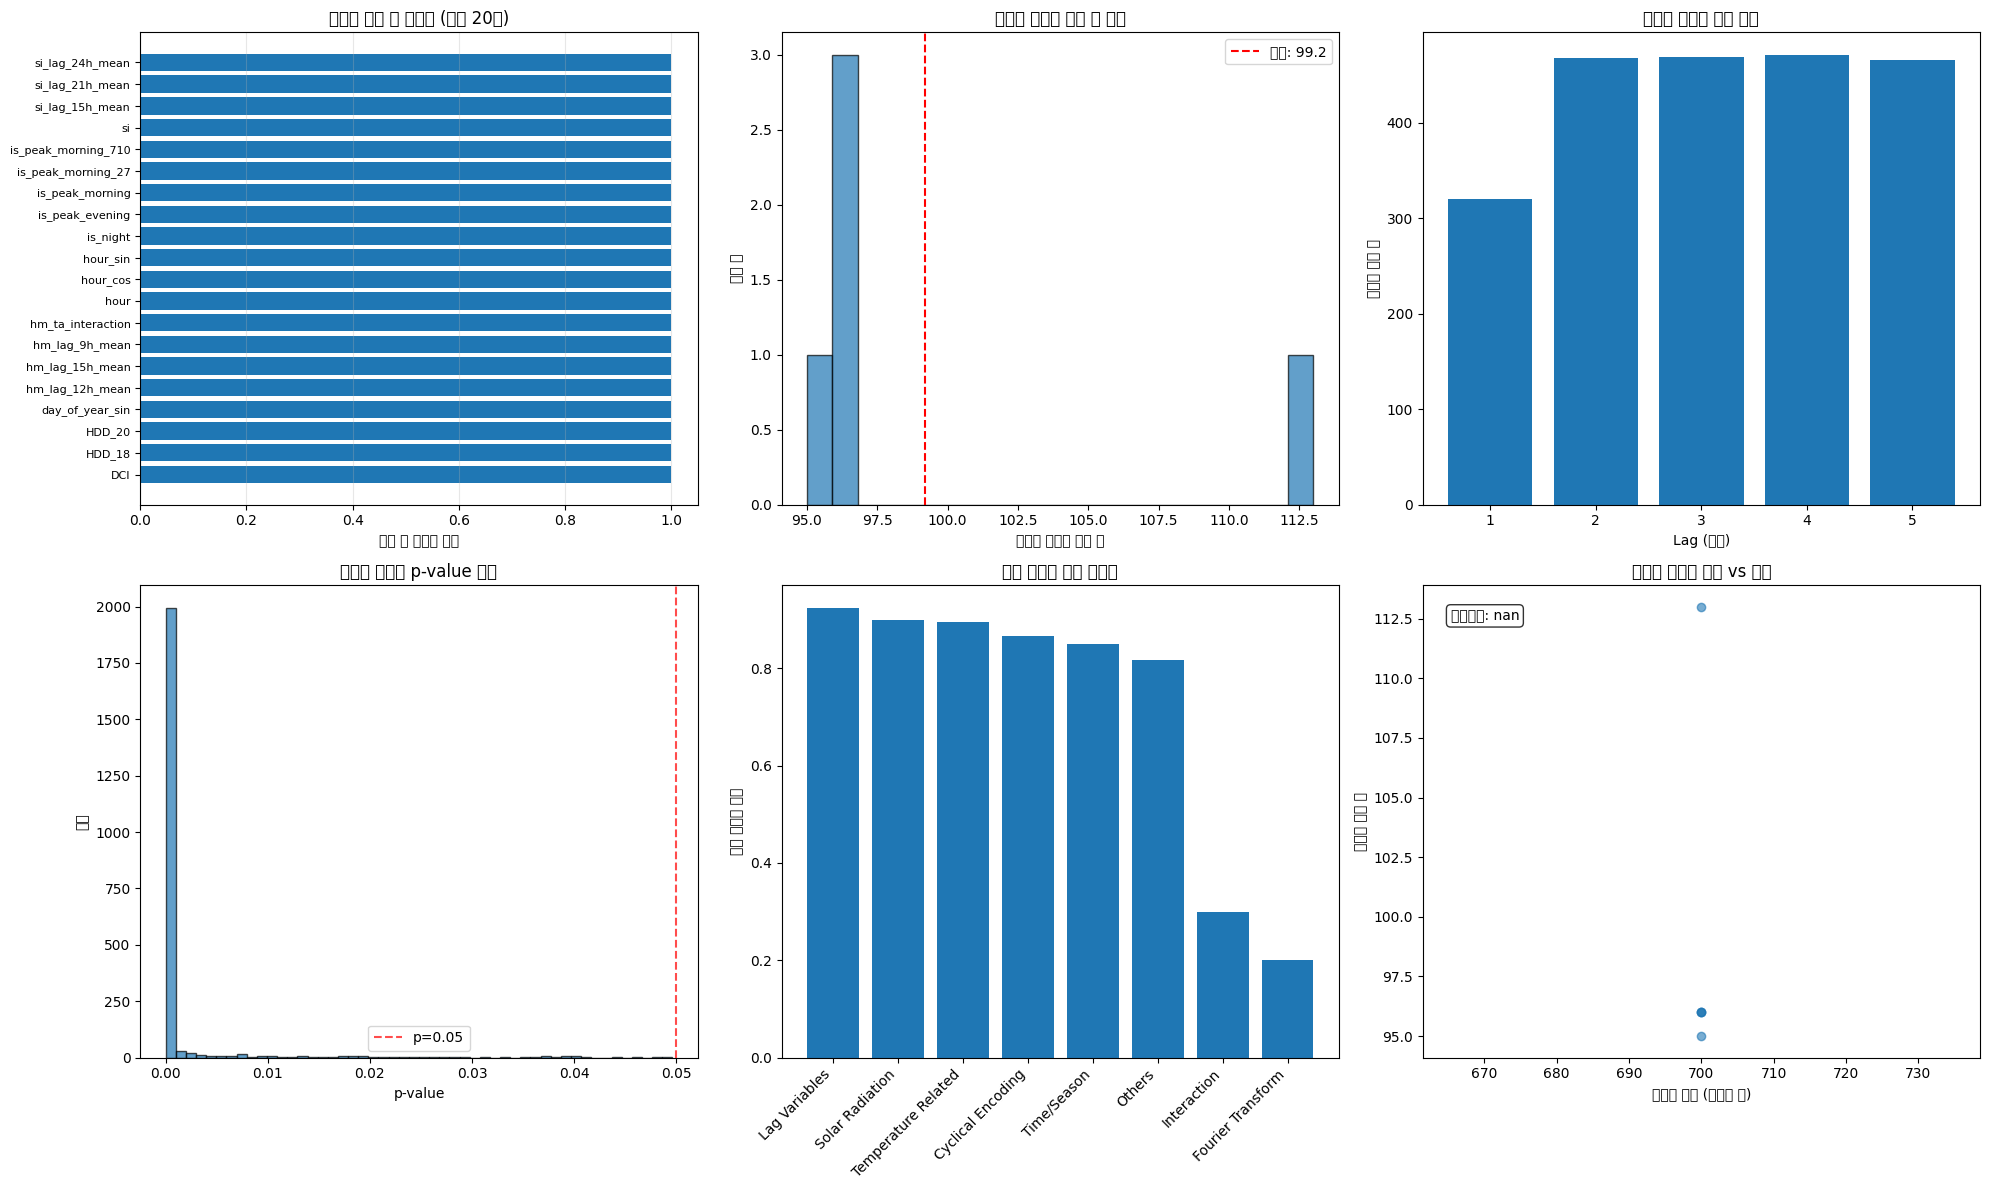


💾 결과 저장 완료:
   - multi_branch_variable_consistency.csv: 변수별 일관성
   - multi_branch_performance.csv: 지사별 성과
   - multi_branch_granger_results.csv: 전체 결과

🎉 전체 분석 완료! 총 소요시간: 15.2분
✅ 테스트 성공! 전체 지사 분석을 진행하시겠습니까?
전체 분석을 원하시면 sample_branches=None으로 설정하여 다시 실행하세요.
🌟 전체 지사 Granger Causality 안정적 분석 시작
🚀 순차적 Granger Causality 분석 시작
📊 전체 데이터 크기: (332861, 145)
🏢 분석 대상 지사: 19개
📈 실제 분석 지사: 19개 (데이터 충분한 지사)


지사별 분석 진행:   0%|          | 0/19 [00:00<?, ?it/s]

In [ ]:

# 실행 코드 (안전한 버전)
if __name__ == "__main__":
    # 전체 지사 분석 실행 (안정적 버전)
    # 먼저 소수 지사로 테스트 해보기
    print("🧪 먼저 5개 지사로 테스트를 진행합니다...")
    
    test_results = run_stable_multi_branch_analysis(
        train_df, 
        target_col='heat_demand', 
        max_lag=5,
        sample_branches=5  # 처음 5개 지사만 테스트
    )
    
    if test_results[0] is not None:
        print("✅ 테스트 성공! 전체 지사 분석을 진행하시겠습니까?")
        print("전체 분석을 원하시면 sample_branches=None으로 설정하여 다시 실행하세요.")
        
        # # 전체 분석을 원할 경우 아래 코드 사용
        # results = run_stable_multi_branch_analysis(
        #     train_df, 
        #     target_col='heat_demand', 
        #     max_lag=5,
        #     sample_branches=None  # 전체 지사
        # )

### 전체 지사

In [ ]:

# 실행 코드 (안전한 버전)
if __name__ == "__main__":
    # 전체 지사 분석 실행 (안정적 버전)
    # 먼저 소수 지사로 테스트 해보기
    print("🧪 전체 지사 대상으로 테스트를 진행합니다...")
    
    test_results = run_stable_multi_branch_analysis(
        train_df, 
        target_col='heat_demand', 
        max_lag=5,
        sample_branches=None  # 전체 지사
        
    )
    
    if test_results[0] is not None:
        print("✅ 테스트 성공! 전체 지사 분석을 진행하시겠습니까?")
        print("전체 분석을 원하시면 sample_branches=None으로 설정하여 다시 실행하세요.")
        
        # # 전체 분석을 원할 경우 아래 코드 사용
        # results = run_stable_multi_branch_analysis(
        #     train_df, 
        #     target_col='heat_demand', 
        #     max_lag=5,
        #     sample_branches=None  # 전체 지사
        # )

🧪 전체 지사 대상으로 테스트를 진행합니다...
🌟 전체 지사 Granger Causality 안정적 분석 시작
🚀 순차적 Granger Causality 분석 시작
📊 전체 데이터 크기: (332861, 145)
🏢 분석 대상 지사: 19개
📈 실제 분석 지사: 19개 (데이터 충분한 지사)


지사별 분석 진행:   5%|▌         | 1/19 [04:34<1:22:13, 274.07s/it]

### Light GBM

In [13]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [14]:


# 상위 30개 일관성 변수 정의
TOP_30_FEATURES = [
    'DCI',
    'HDD_18',
    'HDD_20', 
    'day_of_year_sin',
    'hm_lag_12h_mean',
    'hm_lag_15h_mean',
    'hm_lag_9h_mean',
    'hm_ta_interaction',
    'hour',
    'hour_cos',
    'hour_sin',
    'is_night',
    'is_peak_evening',
    'is_peak_morning',
    'is_peak_morning_27',
    'is_peak_morning_710',
    'si',
    'si_lag_15h_mean',
    'si_lag_21h_mean',
    'si_lag_24h_mean',
    'si_lag_3h_mean',
    'si_lag_9h_mean',
    'ta_chi_lag_18h_mean',
    'ta_chi_lag_21h_mean',
    'ta_chi_lag_24h_mean',
    'ta_chi_lag_6h_mean',
    'ta_diff_12h',
    'ta_humidity_interaction',
    'ta_lag_24h_mean',
    'ta_lag_6h_mean'
]

def load_and_prepare_data(train_path, test_path):
    """데이터 로드 및 준비"""
    print("📊 데이터 로드 중...")
    
    # 데이터 로드
    train_df = pd.read_csv('/Users/jisupark_1/workspace/star_track_python/PRJ_Meteo/dataset/train_data_2122.csv')
    test_df = pd.read_csv('/Users/jisupark_1/workspace/star_track_python/PRJ_Meteo/dataset/test_data_23.csv')
    
    print(f"   훈련 데이터: {train_df.shape}")
    print(f"   테스트 데이터: {test_df.shape}")
    
    # 컬럼명 확인
    print(f"   훈련 데이터 컬럼: {list(train_df.columns)}")
    print(f"   테스트 데이터 컬럼: {list(test_df.columns)}")
    
    # datetime 컬럼 변환
    if 'datetime' in train_df.columns:
        train_df['datetime'] = pd.to_datetime(train_df['datetime'])
        test_df['datetime'] = pd.to_datetime(test_df['datetime'])
    
    return train_df, test_df

def prepare_features(train_df, test_df, feature_list, target_col=None):
    """특성 준비 및 검증"""
    print("🔍 특성 준비 중...")
    
    # 타겟 컬럼 자동 감지
    if target_col is None:
        possible_targets = ['heat_demand', 'target', 'y', 'label']
        for col in possible_targets:
            if col in train_df.columns:
                target_col = col
                break
        
        if target_col is None:
            # 수치형 컬럼 중에서 타겟으로 보이는 컬럼 찾기
            numeric_cols = train_df.select_dtypes(include=[np.number]).columns
            exclude_cols = ['tm', 'branch_id', 'year', 'month', 'day', 'hour', 'dayofweek']
            candidate_targets = [col for col in numeric_cols if col not in exclude_cols and col not in feature_list]
            
            if candidate_targets:
                target_col = candidate_targets[0]  # 첫 번째 후보를 타겟으로 사용
                print(f"   자동 감지된 타겟 컬럼: {target_col}")
            else:
                raise ValueError("타겟 컬럼을 찾을 수 없습니다. 수동으로 지정해주세요.")
    
    print(f"   사용할 타겟 컬럼: {target_col}")
    
    # 사용 가능한 특성 확인
    available_features = []
    missing_features = []
    
    for feature in feature_list:
        if feature in train_df.columns and feature in test_df.columns:
            available_features.append(feature)
        else:
            missing_features.append(feature)
    
    print(f"   사용 가능한 특성: {len(available_features)}개")
    if missing_features:
        print(f"   누락된 특성: {len(missing_features)}개")
        print(f"   누락된 특성 목록: {missing_features[:10]}{'...' if len(missing_features) > 10 else ''}")
    
    # 특성과 타겟 분리
    X_train = train_df[available_features].copy()
    y_train = train_df[target_col].copy()
    X_test = test_df[available_features].copy()
    
    # 결측치 확인 및 처리
    print(f"\n📋 데이터 품질 확인:")
    print(f"   훈련 데이터 결측치: {X_train.isnull().sum().sum()}")
    print(f"   테스트 데이터 결측치: {X_test.isnull().sum().sum()}")
    print(f"   타겟 변수 결측치: {y_train.isnull().sum()}")
    
    # 결측치 처리 (중앙값으로 대체)
    if X_train.isnull().sum().sum() > 0 or X_test.isnull().sum().sum() > 0:
        print("   결측치를 중앙값으로 대체합니다...")
        for col in available_features:
            if X_train[col].isnull().sum() > 0:
                median_val = X_train[col].median()
                X_train[col].fillna(median_val, inplace=True)
                X_test[col].fillna(median_val, inplace=True)
    
    # 무한값 처리
    X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_train.fillna(0, inplace=True)
    X_test.fillna(0, inplace=True)
    
    print(f"   최종 특성 수: {len(available_features)}")
    print(f"   훈련 데이터 크기: {X_train.shape}")
    print(f"   테스트 데이터 크기: {X_test.shape}")
    
    return X_train, y_train, X_test, available_features, target_col

def train_lightgbm_model(X_train, y_train, X_val, y_val, params=None):
    """LightGBM 모델 훈련"""
    
    if params is None:
        params = {
            'objective': 'regression',
            'metric': 'rmse',
            'boosting_type': 'gbdt',
            'num_leaves': 31,
            'learning_rate': 0.1,
            'feature_fraction': 0.8,
            'bagging_fraction': 0.8,
            'bagging_freq': 5,
            'min_child_samples': 20,
            'min_child_weight': 0.001,
            'min_split_gain': 0.0,
            'subsample': 0.8,
            'subsample_freq': 1,
            'colsample_bytree': 0.8,
            'reg_alpha': 0.0,
            'reg_lambda': 0.0,
            'random_state': 42,
            'n_jobs': -1,
            'verbose': -1
        }
    
    # LightGBM 데이터셋 생성
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
    
    # 모델 훈련
    model = lgb.train(
        params,
        train_data,
        valid_sets=[train_data, val_data],
        valid_names=['train', 'valid'],
        num_boost_round=1000,
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=100)
        ]
    )
    
    return model

def cross_validate_model(X, y, feature_names, cv_folds=5):
    """교차 검증으로 모델 성능 평가"""
    print(f"\n🔄 {cv_folds}-Fold 교차 검증 시작...")
    
    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    cv_scores = {
        'rmse': [],
        'mae': [],
        'r2': []
    }
    
    feature_importance_list = []
    models = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        print(f"   Fold {fold}/{cv_folds} 진행 중...")
        
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]
        
        # 모델 훈련
        model = train_lightgbm_model(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
        models.append(model)
        
        # 예측
        y_pred = model.predict(X_val_fold, num_iteration=model.best_iteration)
        
        # 성능 계산
        rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred))
        mae = mean_absolute_error(y_val_fold, y_pred)
        r2 = r2_score(y_val_fold, y_pred)
        
        cv_scores['rmse'].append(rmse)
        cv_scores['mae'].append(mae)
        cv_scores['r2'].append(r2)
        
        # 특성 중요도 저장
        importance = model.feature_importance(importance_type='gain')
        feature_importance_list.append(importance)
        
        print(f"      RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")
    
    # 평균 성능 계산
    avg_scores = {
        'rmse': np.mean(cv_scores['rmse']),
        'mae': np.mean(cv_scores['mae']),
        'r2': np.mean(cv_scores['r2'])
    }
    
    std_scores = {
        'rmse': np.std(cv_scores['rmse']),
        'mae': np.std(cv_scores['mae']),
        'r2': np.std(cv_scores['r2'])
    }
    
    print(f"\n📊 교차 검증 결과:")
    print(f"   RMSE: {avg_scores['rmse']:.4f} ± {std_scores['rmse']:.4f}")
    print(f"   MAE:  {avg_scores['mae']:.4f} ± {std_scores['mae']:.4f}")
    print(f"   R²:   {avg_scores['r2']:.4f} ± {std_scores['r2']:.4f}")
    
    # 평균 특성 중요도 계산
    avg_importance = np.mean(feature_importance_list, axis=0)
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': avg_importance
    }).sort_values('importance', ascending=False)
    
    return models, avg_scores, std_scores, feature_importance_df

def train_final_model(X_train, y_train):
    """전체 훈련 데이터로 최종 모델 훈련"""
    print("\n🎯 최종 모델 훈련 중...")
    
    # 훈련/검증 분할
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42
    )
    
    # 최종 모델 훈련
    final_model = train_lightgbm_model(X_tr, y_tr, X_val, y_val)
    
    # 전체 훈련 데이터에 대한 성능
    y_pred_train = final_model.predict(X_train, num_iteration=final_model.best_iteration)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    train_r2 = r2_score(y_train, y_pred_train)
    
    print(f"   전체 훈련 데이터 성능:")
    print(f"   RMSE: {train_rmse:.4f}")
    print(f"   R²: {train_r2:.4f}")
    
    return final_model

def make_predictions(model, X_test):
    """테스트 데이터 예측"""
    print("\n🔮 테스트 데이터 예측 중...")
    
    predictions = model.predict(X_test, num_iteration=model.best_iteration)
    
    print(f"   예측 완료: {len(predictions)}개 샘플")
    print(f"   예측값 범위: {predictions.min():.2f} ~ {predictions.max():.2f}")
    
    return predictions

def visualize_results(feature_importance_df, predictions, y_train, save_plots=True):
    """결과 시각화"""
    print("\n📈 결과 시각화 중...")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. 특성 중요도 (상위 20개)
    top_features = feature_importance_df.head(20)
    axes[0, 0].barh(range(len(top_features)), top_features['importance'])
    axes[0, 0].set_yticks(range(len(top_features)))
    axes[0, 0].set_yticklabels(top_features['feature'], fontsize=10)
    axes[0, 0].set_xlabel('Feature Importance')
    axes[0, 0].set_title('Top 20 Feature Importance')
    axes[0, 0].grid(axis='x', alpha=0.3)
    
    # 2. 예측값 분포
    axes[0, 1].hist(predictions, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 1].set_xlabel('Predicted Heat Demand')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Distribution of Predictions')
    axes[0, 1].grid(alpha=0.3)
    
    # 3. 훈련 데이터 타겟 분포
    axes[1, 0].hist(y_train, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
    axes[1, 0].set_xlabel('Actual Heat Demand (Training)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Distribution of Training Target')
    axes[1, 0].grid(alpha=0.3)
    
    # 4. 예측값 vs 훈련값 분포 비교
    axes[1, 1].hist(y_train, bins=50, alpha=0.5, label='Training Data', color='lightcoral')
    axes[1, 1].hist(predictions, bins=50, alpha=0.5, label='Predictions', color='skyblue')
    axes[1, 1].set_xlabel('Heat Demand')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Training vs Prediction Distribution')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig('lightgbm_results.png', dpi=300, bbox_inches='tight')
        print("   📁 시각화 결과 저장: lightgbm_results.png")
    
    plt.show()

def save_results(predictions, test_df, feature_importance_df, cv_scores):
    """결과 저장"""
    print("\n💾 결과 저장 중...")
    
    # 예측 결과 저장
    if 'datetime' in test_df.columns and 'branch_id' in test_df.columns:
        results_df = pd.DataFrame({
            'datetime': test_df['datetime'],
            'branch_id': test_df['branch_id'],
            'predicted_heat_demand': predictions
        })
    else:
        results_df = pd.DataFrame({
            'predicted_heat_demand': predictions
        })
    
    results_df.to_csv('lightgbm_predictions.csv', index=False)
    print("   📁 예측 결과 저장: lightgbm_predictions.csv")
    
    # 특성 중요도 저장
    feature_importance_df.to_csv('feature_importance.csv', index=False)
    print("   📁 특성 중요도 저장: feature_importance.csv")
    
    # 성능 지표 저장
    performance_df = pd.DataFrame({
        'metric': ['RMSE', 'MAE', 'R2'],
        'mean': [cv_scores['rmse'], cv_scores['mae'], cv_scores['r2']]
    })
    performance_df.to_csv('model_performance.csv', index=False)
    print("   📁 모델 성능 저장: model_performance.csv")

def main():
    """메인 실행 함수"""
    print("🚀 LightGBM 모델링 시작 (Top 30 일관성 변수)")
    print("="*60)
    
    # 1. 데이터 로드
    train_df, test_df = load_and_prepare_data('train_data_2122.csv', 'test_data_23.csv')
    
    # 2. 특성 준비
    X_train, y_train, X_test, feature_names, target_col = prepare_features(
        train_df, test_df, TOP_30_FEATURES
    )
    
    # 사용 가능한 특성이 있는지 확인
    if len(feature_names) == 0:
        print("❌ 사용 가능한 특성이 없습니다. 데이터를 확인해주세요.")
        return
    
    if len(feature_names) < 5:
        print(f"⚠️ 사용 가능한 특성이 {len(feature_names)}개로 적습니다. 모델 성능이 제한될 수 있습니다.")
    
    # 3. 교차 검증
    models, cv_scores, cv_std, feature_importance_df = cross_validate_model(
        X_train, y_train, feature_names
    )
    
    # 4. 최종 모델 훈련
    final_model = train_final_model(X_train, y_train)
    
    # 5. 예측 수행
    predictions = make_predictions(final_model, X_test)
    
    # 6. 결과 시각화
    visualize_results(feature_importance_df, predictions, y_train)
    
    # 7. 결과 저장
    save_results(predictions, test_df, feature_importance_df, cv_scores)
    
    print("\n🎉 모델링 완료!")
    print("="*60)
    print(f"📊 최종 성능 (CV 평균):")
    print(f"   RMSE: {cv_scores['rmse']:.4f} ± {cv_std['rmse']:.4f}")
    print(f"   MAE:  {cv_scores['mae']:.4f} ± {cv_std['mae']:.4f}")
    print(f"   R²:   {cv_scores['r2']:.4f} ± {cv_std['r2']:.4f}")
    print(f"\n🔝 상위 5개 중요 특성:")
    for i, (_, row) in enumerate(feature_importance_df.head(5).iterrows()):
        print(f"   {i+1}. {row['feature']}: {row['importance']:.0f}")
    print(f"\n🎯 사용된 타겟 변수: {target_col}")
    print(f"🔢 사용된 특성 수: {len(feature_names)}개")

if __name__ == "__main__":
    main()

🚀 LightGBM 모델링 시작 (Top 30 일관성 변수)
📊 데이터 로드 중...
   훈련 데이터: (332861, 12)
   테스트 데이터: (166440, 12)
   훈련 데이터 컬럼: ['Unnamed: 0', 'train_heat.tm', 'train_heat.branch_id', 'train_heat.ta', 'train_heat.wd', 'train_heat.ws', 'train_heat.rn_day', 'train_heat.rn_hr1', 'train_heat.hm', 'train_heat.si', 'train_heat.ta_chi', 'train_heat.heat_demand']
   테스트 데이터 컬럼: ['Unnamed: 0', 'train_heat.tm', 'train_heat.branch_id', 'train_heat.ta', 'train_heat.wd', 'train_heat.ws', 'train_heat.rn_day', 'train_heat.rn_hr1', 'train_heat.hm', 'train_heat.si', 'train_heat.ta_chi', 'train_heat.heat_demand']
🔍 특성 준비 중...
   자동 감지된 타겟 컬럼: Unnamed: 0
   사용할 타겟 컬럼: Unnamed: 0
   사용 가능한 특성: 0개
   누락된 특성: 30개
   누락된 특성 목록: ['DCI', 'HDD_18', 'HDD_20', 'day_of_year_sin', 'hm_lag_12h_mean', 'hm_lag_15h_mean', 'hm_lag_9h_mean', 'hm_ta_interaction', 'hour', 'hour_cos']...

📋 데이터 품질 확인:
   훈련 데이터 결측치: 0.0
   테스트 데이터 결측치: 0.0
   타겟 변수 결측치: 0
   최종 특성 수: 0
   훈련 데이터 크기: (332861, 0)
   테스트 데이터 크기: (166440, 0)
❌ 사용 가능한 특성이 없습니다. 